In [1]:
from resources.imports import *
from resources.MLdata import *

# Interpolation Methods

## RBF Interpolation

In [2]:
def phi(x):
    F = np.sin(2 * np.pi * x) * np.cos(5 * np.pi * x)
    return F

def gaussian(x1, x2, l = 1):
    f = np.exp(-(x1 - x2) ** 2 / (2 * l ** 2))
    return f

def kernel_matrix(X, l = 1, f = gaussian):
    G = np.zeros([len(X), len(X)])
    for i in range(len(X)):
        for j in range(len(X)):
            G[i, j] = f(X[i], X[j], l)
    return G

def rbf_model(G, d):
    m = np.dot(np.linalg.inv(G), d)
    return m

def rbf_predict(x, X, m, l = 1, f = gaussian):
    S = np.zeros(len(x))
    for i in range(len(m)):
        S = S + m[i] * f(x, X[i], l)
    return S

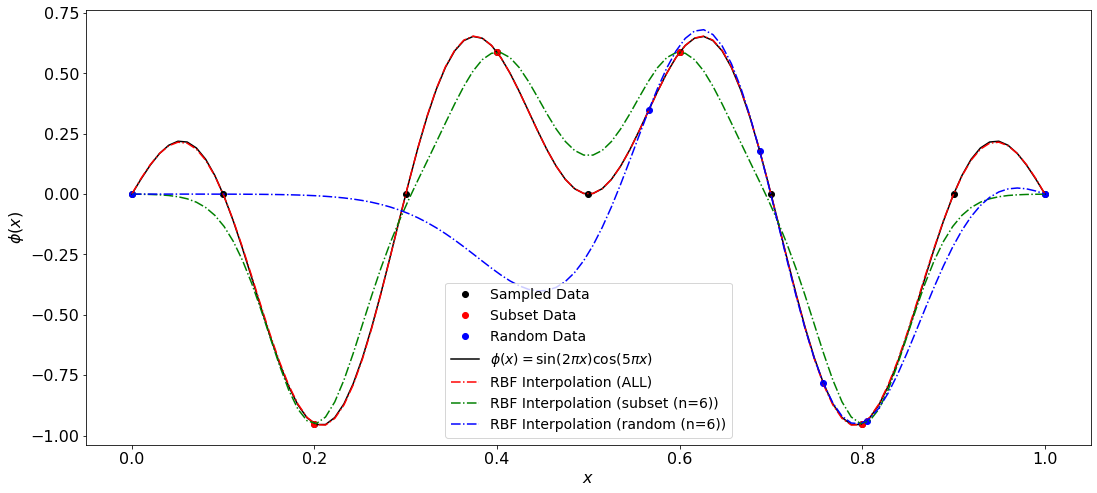

In [3]:
# Sample 10 values of X and phi.
N = 10
X = np.arange(0, N + 1, 1) / N
d = phi(X)

X_ = np.arange(2, 9, 2) / 10
d_ = phi(X_)

Xr = np.array([0.0] + [random.random() for i in range(4)] + [1.0])
dr = phi(Xr)
# Gaussian length scale.
L = 1 / 9
L_ = 1 / 20
Lr = 1 / 9

# Calculate the kernel matrix G
G = kernel_matrix(X, L, gaussian)
G_ = kernel_matrix(X_, L_, gaussian)
Gr = kernel_matrix(Xr, Lr, gaussian)

# Invert d = Gm for the model parameters.
m = rbf_model(G, d)
m_ = rbf_model(G_, d_)
mr = rbf_model(Gr, dr)

# Using m, interpolate phi for all values in x ∈ [0, 1].
x = np.linspace(0, 1, 100)
S = rbf_predict(x, X, m, L, gaussian)
S_ = rbf_predict(x, X_, m_, L_, gaussian)
Sr = rbf_predict(x, Xr, mr, Lr, gaussian)

# Plot the results.
plt.figure(figsize = [18, 8])
plt.plot(X, d, "ko", label="Sampled Data")     # Sampled discrete data points of phi.
plt.plot(X_, d_, "ro", label="Subset Data")     # Sampled discrete data points of phi.
plt.plot(Xr, dr, "bo", label="Random Data")     # Sampled discrete data points of phi.

plt.plot(x, phi(x), "k", label="$\phi(x) = \sin(2 \pi x) \cos(5 \pi x)$") # True "continuous" values of phi.
plt.plot(x, S, "r-.", label="RBF Interpolation (ALL)")    # # Interpolated values of phi.
plt.plot(x, S_, "g-.", label="RBF Interpolation (subset (n=6))")     # Sampled discrete data points of phi.
plt.plot(x, Sr, "b-.", label="RBF Interpolation (random (n=6))")     # Sampled discrete data points of phi.

plt.legend(fontsize = 14)
plt.xlabel("$x$", fontsize = 16)
plt.ylabel("$\phi(x)$", fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.show()


# # Plots the weighted Gaussians used in the interpolation model.
# plt.figure(1, figsize = [18, 4])
# for i in range(len(m)):
#     plt.plot(m[i] * gaussian(x, X[i], L))
# plt.legend(range(len(m)), fontsize = 14)
# plt.xlabel("$x$", fontsize = 16)
# plt.ylabel("$f(x)$", fontsize = 16)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# plt.show()

# plt.figure(2, figsize = [18, 4])
# for i in range(len(m_)):
#     plt.plot(m_[i] * gaussian(x, X_[i], L_))
# plt.legend(range(len(m_)), fontsize = 14)
# plt.xlabel("$x$", fontsize = 16)
# plt.ylabel("$f(x)$", fontsize = 16)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# plt.show()

# plt.figure(3, figsize = [18, 4])
# for i in range(len(mr)):
#     plt.plot(mr[i] * gaussian(x, Xr[i], Lr))
# plt.legend(range(len(mr)), fontsize = 14)
# plt.xlabel("$x$", fontsize = 16)
# plt.ylabel("$f(x)$", fontsize = 16)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# plt.show()

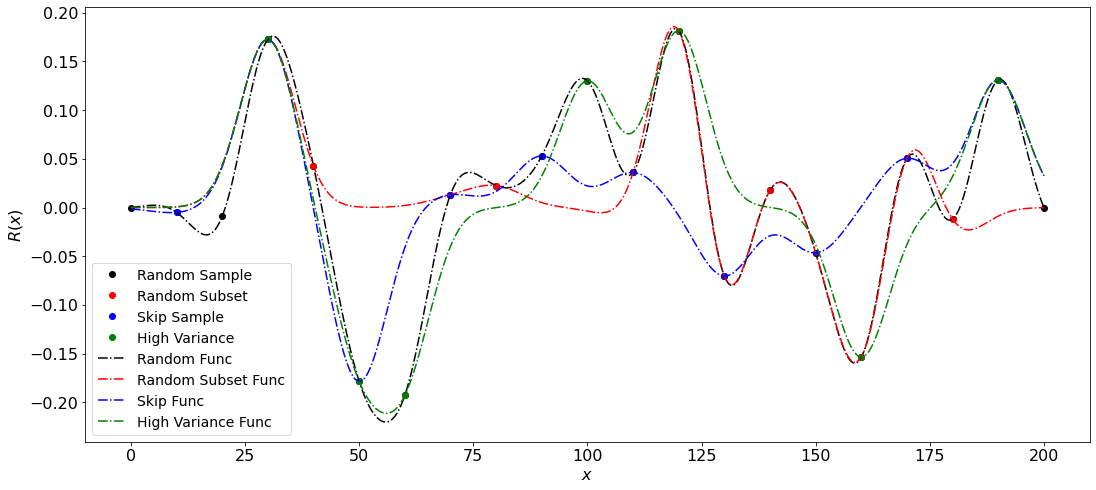

Sample size : 21
 Subset   : 56.99999999999999%
 Skip     : 47.62%
 Variance : 33.33%

Mean Absolute Error:
 Subset   : 0.0359
 Skip     : 0.0401
 Variance : 0.0256


In [4]:
N = 200
X = np.arange(0, N + 1, 10)
d = np.array([0.5]+[random.random() for i in range(len(X)-2)]+[0.5])*0.4 - 0.2

X_, d_ = zip(*random.sample(list(zip(X, d)), int(0.6*len(X))))

X_skip = [X[i] for i in range(1, len(X), 2)]
d_skip = [d[i] for i in range(1, len(d), 2)]

mu = np.mean(d)
var = np.std(d)

dv = np.array([dd for i,dd in enumerate(d) if dd > mu+var or dd < mu-var])
dv_ind = [d.tolist().index(i) for i in dv if i in d]
Xv = X[dv_ind]

# Gaussian length scale.
L = 6

# Calculate the kernel matrix G
G = kernel_matrix(X, L, gaussian)
G_ = kernel_matrix(X_, L, gaussian)
Gv = kernel_matrix(Xv, L, gaussian)
G_skip = kernel_matrix(X_skip, L, gaussian)

# Invert d = Gm for the model parameters.
m = rbf_model(G, d)
m_ = rbf_model(G_, d_)
mv = rbf_model(Gv, dv)
m_skip = rbf_model(G_skip, d_skip)

# Using m, interpolate phi for all values in x ∈ [0, 1].
x = np.linspace(0, 200, 1000)
S = rbf_predict(x, X, m, L, gaussian)
S_ = rbf_predict(x, X_, m_, L, gaussian)
Sv = rbf_predict(x, Xv, mv, L, gaussian)
S_skip = rbf_predict(x, X_skip, m_skip, L, gaussian)

# Plot the results.
plt.figure(figsize = [18, 8])
plt.plot(X, d, "ko", label="Random Sample")     # Sampled discrete data points of phi.
plt.plot(X_, d_, "ro", label="Random Subset")     # Sampled discrete data points of phi.
plt.plot(X_skip, d_skip, "bo", label="Skip Sample")     # Sampled discrete data points of phi.
plt.plot(Xv, dv, "go", label="High Variance")     # Sampled discrete data points of phi.
plt.plot(x, S, "k-.", label="Random Func")    # # Interpolated values of phi.
plt.plot(x, S_, "r-.", label="Random Subset Func")     # Sampled discrete data points of phi.
plt.plot(x, S_skip, "b-.", label="Skip Func")     # Sampled discrete data points of phi.
plt.plot(x, Sv, "g-.", label="High Variance Func")     # Sampled discrete data points of phi.

plt.legend(fontsize = 14)
plt.xlabel("$x$", fontsize = 16)
plt.ylabel("$R(x)$", fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.show()


# # Plots the weighted Gaussians used in the interpolation model.
# plt.figure(1, figsize = [18, 4])
# for i in range(len(m)):
#     plt.plot(m[i] * gaussian(x, X[i], L))
# plt.legend(range(len(m)), fontsize = 14)
# plt.xlabel("$x$", fontsize = 16)
# plt.ylabel("$f(x)$", fontsize = 16)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# plt.show()

# plt.figure(2, figsize = [18, 4])
# for i in range(len(m_)):
#     plt.plot(m_[i] * gaussian(x, X_[i], L_))
# plt.legend(range(len(m)), fontsize = 14)
# plt.xlabel("$x$", fontsize = 16)
# plt.ylabel("$f(x)$", fontsize = 16)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# plt.show()

print(f"Sample size : {len(X)}")
print(f" Subset   : {np.round(len(X_)/len(X),2)*100}%")
print(f" Skip     : {np.round(len(X_skip)/len(X)*100,2)}%")
print(f" Variance : {np.round(len(Xv)/len(X)*100,2)}%")
print("")
print("Mean Absolute Error:")
print(f" Subset   : {np.round(np.mean(abs(rbf_predict(X, X_, m_, L, gaussian)-d)),4)}")
print(f" Skip     : {np.round(np.mean(abs(rbf_predict(X, X_skip, m_skip, L, gaussian)-d)),4)}")
print(f" Variance : {np.round(np.mean(abs(rbf_predict(X, Xv, mv, L, gaussian)-d)),4)}")


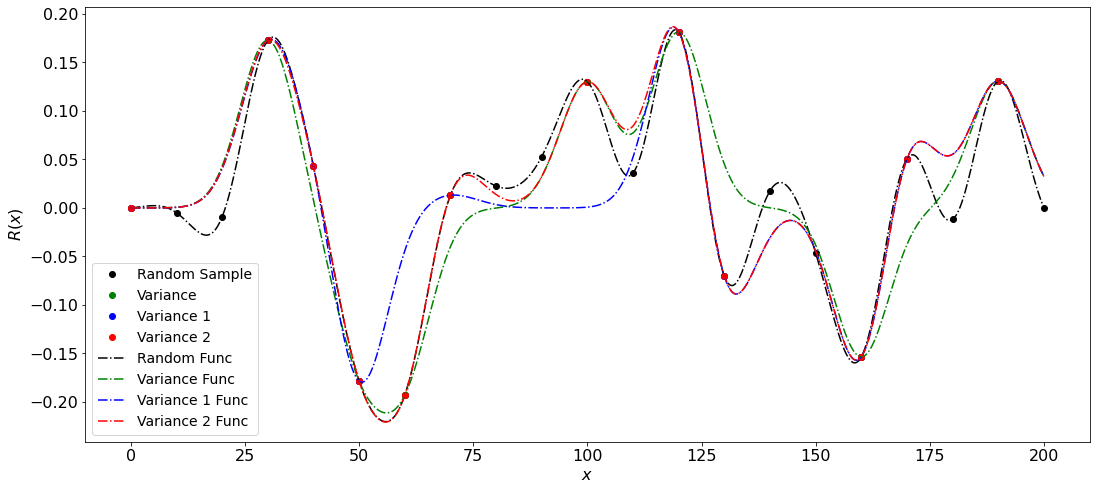

Sample size : 21
 Variance  : 33.0%
 Varaince1 : 47.62%
 Variance2 : 57.14%

Mean Absolute Error:
 Variance  : 0.0256
 Variance1 : 0.0272
 Variance2 : 0.0135


In [5]:
dv = np.array([dd for i,dd in enumerate(d) if dd > mu+var or dd < mu-var])
dv_ind = [d.tolist().index(i) for i in dv if i in d]
Xv = X[dv_ind]

dv1 = np.array([dd for i,dd in enumerate(d) if abs(dd-d[i-1])>var])
dv1_ind = [d.tolist().index(i) for i in dv1 if i in d]
Xv1 = X[dv1_ind]

dv2 = np.array([dd for i,dd in enumerate(d) if dd > mu+var or dd < mu-var or abs(dd-d[i-1])>var])
dv2_ind = [d.tolist().index(i) for i in dv2 if i in d]
Xv2 = X[dv2_ind]

# Gaussian length scale.
L = 6

# Calculate the kernel matrix G
Gv = kernel_matrix(Xv, L, gaussian)
Gv1 = kernel_matrix(Xv1, L, gaussian)
Gv2 = kernel_matrix(Xv2, L, gaussian)

# Invert d = Gm for the model parameters.
mv = rbf_model(Gv, dv)
mv1 = rbf_model(Gv1, dv1)
mv2 = rbf_model(Gv2, dv2)

# Using m, interpolate phi for all values in x ∈ [0, 1].
x = np.linspace(0, 200, 1000)
Sv = rbf_predict(x, Xv, mv, L, gaussian)
Sv1 = rbf_predict(x, Xv1, mv1, L, gaussian)
Sv2 = rbf_predict(x, Xv2, mv2, L, gaussian)

# Plot the results.
plt.figure(figsize = [18, 8])
plt.plot(X, d, "ko", label="Random Sample")     # Sampled discrete data points of phi.
plt.plot(Xv, dv, "go", label="Variance")     # Sampled discrete data points of phi.
plt.plot(Xv1, dv1, "bo", label="Variance 1")     # Sampled discrete data points of phi.
plt.plot(Xv2, dv2, "ro", label="Variance 2")     # Sampled discrete data points of phi.
plt.plot(x, S, "k-.", label="Random Func")    # # Interpolated values of phi.
plt.plot(x, Sv, "g-.", label="Variance Func")     # Sampled discrete data points of phi.
plt.plot(x, Sv1, "b-.", label="Variance 1 Func")     # Sampled discrete data points of phi.
plt.plot(x, Sv2, "r-.", label="Variance 2 Func")     # Sampled discrete data points of phi.

plt.legend(fontsize = 14)
plt.xlabel("$x$", fontsize = 16)
plt.ylabel("$R(x)$", fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.show()


# # Plots the weighted Gaussians used in the interpolation model.
# plt.figure(1, figsize = [18, 4])
# for i in range(len(m)):
#     plt.plot(m[i] * gaussian(x, X[i], L))
# plt.legend(range(len(m)), fontsize = 14)
# plt.xlabel("$x$", fontsize = 16)
# plt.ylabel("$f(x)$", fontsize = 16)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# plt.show()

# plt.figure(2, figsize = [18, 4])
# for i in range(len(m_)):
#     plt.plot(m_[i] * gaussian(x, X_[i], L_))
# plt.legend(range(len(m)), fontsize = 14)
# plt.xlabel("$x$", fontsize = 16)
# plt.ylabel("$f(x)$", fontsize = 16)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# plt.show()

print(f"Sample size : {len(X)}")
print(f" Variance  : {np.round(len(Xv)/len(X),2)*100}%")
print(f" Varaince1 : {np.round(len(Xv1)/len(X)*100,2)}%")
print(f" Variance2 : {np.round(len(Xv2)/len(X)*100,2)}%")
print("")
print("Mean Absolute Error:")
print(f" Variance  : {np.round(np.mean(abs(rbf_predict(X, Xv, mv, L, gaussian)-d)),4)}")
print(f" Variance1 : {np.round(np.mean(abs(rbf_predict(X, Xv1, mv1, L, gaussian)-d)),4)}")
print(f" Variance2 : {np.round(np.mean(abs(rbf_predict(X, Xv2, mv2, L, gaussian)-d)),4)}")

## Spline Interpolation

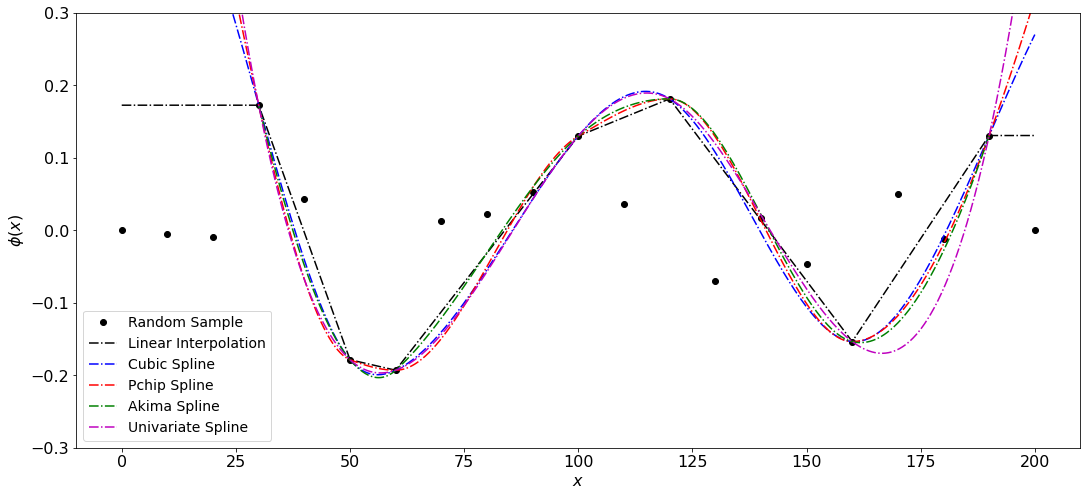

Cubic Spline: Knots = (7,), Coefficients = (4, 6)
Pchip Spline: Knots = (7,), Coefficients = (4, 6)
Akima Spline: Knots = (7,), Coefficients = (4, 6)
Univariate Spline: Knots = (5,), Coefficients = (7,)


In [6]:
from scipy.interpolate import CubicSpline, PchipInterpolator, Akima1DInterpolator, UnivariateSpline, splrep

X_spl, d_spl = Xv, dv
spl = CubicSpline(X_spl, d_spl, bc_type='natural')
Pspl = PchipInterpolator(X_spl, d_spl)
Aspl = Akima1DInterpolator(X_spl, d_spl)
UVspl = UnivariateSpline(X_spl, d_spl, s=0)

plt.figure(figsize = [18, 8])
plt.plot(X, d, "ko", label="Random Sample")     # Sampled discrete data points of phi.
plt.plot(x, np.interp(x, X_spl, d_spl), "k-.", label="Linear Interpolation") # True "continuous" values of phi.
plt.plot(x, spl(x), "b-.", label="Cubic Spline")    # # Interpolated values of phi.
plt.plot(x, Pspl(x), "r-.", label="Pchip Spline")     # Sampled discrete data points of phi.
plt.plot(x, Aspl(x), "g-.", label="Akima Spline")     # Sampled discrete data points of phi.
plt.plot(x, UVspl(x), "m-.", label="Univariate Spline")     # Sampled discrete data points of phi.

plt.legend(fontsize = 14)
plt.xlabel("$x$", fontsize = 16)
plt.ylabel("$\phi(x)$", fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.ylim(-0.3, 0.3)
plt.show()

print(f"Cubic Spline: Knots = {spl.x.shape}, Coefficients = {spl.c.shape}")
print(f"Pchip Spline: Knots = {Pspl.x.shape}, Coefficients = {Pspl.c.shape}")
print(f"Akima Spline: Knots = {Aspl.x.shape}, Coefficients = {Aspl.c.shape}")
print(f"Univariate Spline: Knots = {UVspl.get_knots().shape}, Coefficients = {UVspl.get_coeffs().shape}")

# Approximation Methods

## Fourier Series

In [7]:
DAT = DATA(path=1, load=True, LAT="tri", format=1)

x = DAT.train_in1[:,0]
y = DAT.train_in1[:,1]
z = DAT.dx_out1[0].flatten()

Number of Fourier coefficients needed for <=5% error: 633. 
Number of nodes: 711
Relative reconstruction error: 0.2233


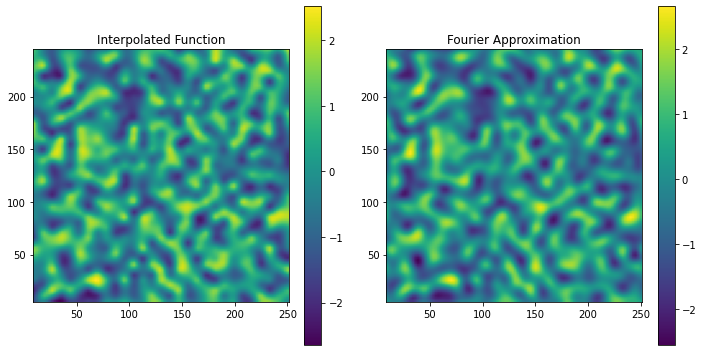

In [9]:
from scipy.interpolate import Rbf, RegularGridInterpolator
from numpy.fft import fft, ifft, fftshift, ifftshift
from numpy.fft import fft2, ifft2, fftshift, ifftshift

# 1. Interpolate onto a uniform grid
grid_size = 100  # you can adjust resolution
xi = np.linspace(x.min(), x.max(), grid_size)
yi = np.linspace(y.min(), y.max(), grid_size)
Xi, Yi = np.meshgrid(xi, yi)

# RBF interpolation to estimate the continuous function
rbf = Rbf(x, y, z, function='thin_plate')  # try 'multiquadric', 'gaussian', etc.
Zi = rbf(Xi, Yi)

# 2. Compute 2D Fourier coefficients via FFT
F_fft = fft2(Zi)
F_shifted = fftshift(F_fft)
power = np.abs(F_shifted)**2

# Flatten and sort coefficients by descending power
power_flat = power.flatten()
idx_sorted = np.argsort(power_flat)[::-1]
cumulative = np.cumsum(power_flat[idx_sorted])
total_energy = cumulative[-1]

# 3. Identify minimal number of coefficients for <=5% error (i.e., >=95% energy)
threshold = 0.95 * total_energy
m = np.searchsorted(cumulative, threshold) + 1
print(f"Number of Fourier coefficients needed for <=5% error: {m}. \nNumber of nodes: {len(z)}")

# 4. Truncate coefficients and reconstruct approximation
mask = np.zeros_like(F_shifted, dtype=bool).flatten()
mask[idx_sorted[:m]] = True
mask = mask.reshape(F_shifted.shape)

F_trunc = F_shifted * mask
Z_approx = np.real(ifft2(ifftshift(F_trunc)))

# 5. Compute relative error on the grid
rel_error = np.linalg.norm(Z_approx - Zi) / np.linalg.norm(Zi)
print(f"Relative reconstruction error: {rel_error:.4f}")

# Optional: Plot original vs. approximation
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(Zi, extent=[xi.min(), xi.max(), yi.min(), yi.max()], origin='lower')
plt.title("Interpolated Function")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(Z_approx, extent=[xi.min(), xi.max(), yi.min(), yi.max()], origin='lower')
plt.title("Fourier Approximation")
plt.colorbar()

plt.tight_layout()
plt.show()

In [10]:
# 1. take the top-m flattened indices
top_flat = idx_sorted[:m]

# 2. convert to 2D grid indices
rows, cols = np.unravel_index(top_flat, F_shifted.shape)

# 3. grab their complex values
values = F_shifted[rows, cols]

# 4. (optional) compute the corresponding frequency for each index
G = F_shifted.shape[0]
# assume a square grid and uniform spacing dx=dy
dx = xi[1] - xi[0]  
freqs = np.fft.fftshift(np.fft.fftfreq(G, d=dx))
# freq in x–direction is freqs[cols],  in y–direction is freqs[rows]

# 5. print or store them
# for r, c, val in zip(rows, cols, values):
#     fx, fy = freqs[c], freqs[r]
#     print(f"mode @ (i={r}, j={c}) → freq=(fx={fx:.3f}, fy={fy:.3f}) \t coeff = {val:.4e}")
df = pd.DataFrame({
    'i':    rows,
    'j':    cols,
    'fx':   freqs[cols],
    'fy':   freqs[rows],
    'value': values
})
df


,i,j,fx,fy,value
0,52,44,-0.024496,0.008165,937.625280+316.080464j
1,48,56,0.024496,-0.008165,937.625280-316.080464j
2,54,42,-0.032662,0.016331,-861.427015+427.794002j
3,46,58,0.032662,-0.016331,-861.427015-427.794002j
4,45,42,-0.032662,-0.020413,-679.122847+605.452562j
...,...,...,...,...,...
628,58,39,-0.044910,0.032662,109.054188-72.179661j
629,46,42,-0.032662,-0.016331,84.7096740+99.2489140j
630,54,58,0.032662,0.016331,84.7096740-99.2489140j
631,47,33,-0.069406,-0.012248,100.236078-83.153407j


Original data points: 711
Target relative error: 5.0%

Step 1: Computing 1D FFT...
Total 1D FFT coefficients: 711

Step 2: Finding minimal coefficients for target error...
  m =   50, Error = 0.85847
  m =  100, Error = 0.76128
  m =  150, Error = 0.67901
  m =  200, Error = 0.60194
  m =  250, Error = 0.52689
  m =  300, Error = 0.45805
  m =  350, Error = 0.39570
  m =  400, Error = 0.33537
  m =  450, Error = 0.28137
  m =  500, Error = 0.22644
  m =  550, Error = 0.17197
  m =  600, Error = 0.11758
  m =  650, Error = 0.06351

Target relative error 5.0% reached!
Number of 1D coefficients needed: 664
Final relative error: 0.0493
Calculation took 0.03 seconds.

Reduced dimensionality: 664 complex 1D coefficients.

Step 3: Visualizing results...


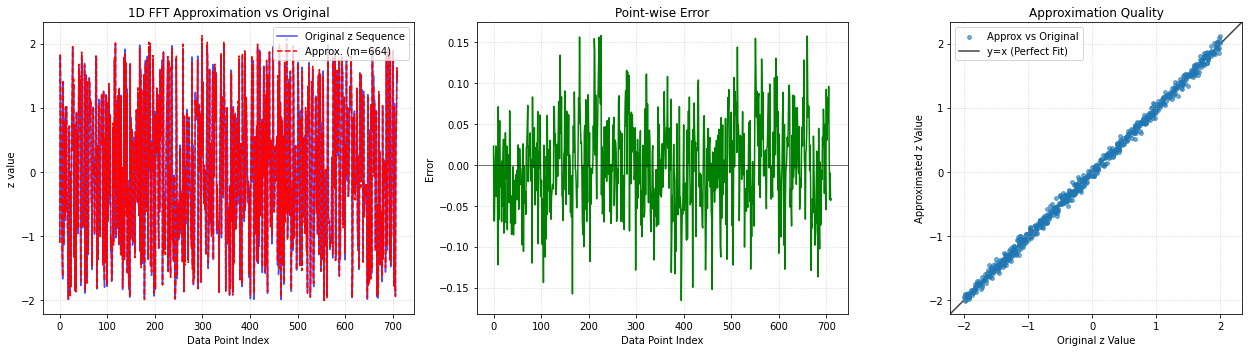

In [11]:
z_flat = z # Treat z as a 1D sequence
N_points = len(z_flat)

# --- Parameters ---
TARGET_RELATIVE_ERROR = 0.05

print(f"Original data points: {N_points}")
print(f"Target relative error: {TARGET_RELATIVE_ERROR:.1%}")

start_time = time.time()

# --- 1. Compute 1D FFT ---
print("\nStep 1: Computing 1D FFT...")
F_fft = fft(z_flat)
# Shift zero frequency to center for magnitude sorting
F_shifted = fftshift(F_fft)
total_coeffs = len(F_shifted)
print(f"Total 1D FFT coefficients: {total_coeffs}")

# --- 2. Calculate Power and Sort Indices ---
power = np.abs(F_shifted)**2
idx_sorted = np.argsort(power)[::-1] # Indices from highest power to lowest

# --- 3. Iteratively find minimal coefficients ---
print("\nStep 2: Finding minimal coefficients for target error...")
z_norm_factor = np.linalg.norm(z_flat)
if z_norm_factor == 0:
    print("Warning: Original z data has zero norm. Relative error is ill-defined.")
    z_norm_factor = 1.0

best_m = -1
final_error = -1
final_coeffs_mask = None
final_z_approx = None

for m in range(1, total_coeffs + 1):
    # Create mask for top 'm' coefficients
    mask = np.zeros(total_coeffs, dtype=bool)
    mask[idx_sorted[:m]] = True

    # Apply mask in shifted domain
    F_trunc_shifted = F_shifted * mask

    # Inverse shift and inverse FFT
    # Important: Apply ifftshift BEFORE ifft
    z_approx = np.real(ifft(ifftshift(F_trunc_shifted)))

    # Calculate relative error
    current_error = np.linalg.norm(z_flat - z_approx) / z_norm_factor

    # Check target
    if current_error <= TARGET_RELATIVE_ERROR:
        print(f"\nTarget relative error {TARGET_RELATIVE_ERROR:.1%} reached!")
        print(f"Number of 1D coefficients needed: {m}")
        print(f"Final relative error: {current_error:.4f}")
        best_m = m
        final_error = current_error
        final_coeffs_mask = mask
        final_z_approx = z_approx
        break # Exit loop

    # Optional: Print progress occasionally
    if m % 50 == 0:
         print(f"  m = {m:4d}, Error = {current_error:.5f}")

else:
    # If loop finishes without break
    print("\nTarget relative error not reached.")
    print(f"Minimum error achieved: {current_error:.4f} with {m} coefficients.")
    best_m = m
    final_error = current_error
    final_coeffs_mask = mask
    final_z_approx = z_approx

end_time = time.time()
print(f"Calculation took {end_time - start_time:.2f} seconds.")

# --- 4. Reduced Representation ---
if best_m > 0:
    print(f"\nReduced dimensionality: {best_m} complex 1D coefficients.")
    # Extract the kept coefficients (optional)
    kept_coefficients_1d = F_shifted[final_coeffs_mask]
    # The mask 'final_coeffs_mask' implicitly stores frequency info needed for reconstruction
    # Or you could store 'idx_sorted[:best_m]' and the values 'kept_coefficients_1d'

# --- 5. Visualization ---
print("\nStep 3: Visualizing results...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
indices = np.arange(N_points)


axes[0].plot(indices, z_flat, label='Original z Sequence', color='blue', alpha=0.7)
axes[0].plot(indices, final_z_approx, label=f'Approx. (m={best_m})', color='red', linestyle='--')
axes[0].set_xlabel("Data Point Index")
axes[0].set_ylabel("z value")
axes[0].set_title("1D FFT Approximation vs Original")
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)


pointwise_error = z_flat - final_z_approx
axes[1].plot(indices, pointwise_error, label='Error (Original - Approx)', color='green')
axes[1].set_xlabel("Data Point Index")
axes[1].set_ylabel("Error")
axes[1].set_title("Point-wise Error")
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].axhline(0, color='black', linewidth=0.5)


# Plot 3: Scatter Comparison (Diagonal Plot)
axes[2].scatter(z_flat, final_z_approx, label='Approx vs Original', alpha=0.6, s=15)
# Add diagonal line y=x for reference
lims = [
    np.min([axes[2].get_xlim(), axes[2].get_ylim()]),  # min of both axes
    np.max([axes[2].get_xlim(), axes[2].get_ylim()]),  # max of both axes
]
axes[2].plot(lims, lims, 'k-', alpha=0.75, zorder=0, label='y=x (Perfect Fit)')
axes[2].set_xlim(lims)
axes[2].set_ylim(lims)
axes[2].set_xlabel("Original z Value")
axes[2].set_ylabel("Approximated z Value")
axes[2].set_title("Approximation Quality")
axes[2].grid(True, linestyle=':', alpha=0.6)
axes[2].set_aspect('equal', adjustable='box') # Make axes equal scale
axes[2].legend()


plt.tight_layout()
plt.show()

Original data points: 711
Target relative error: 5.0%
Grid size for FFT: 100x100
RBF function: thin_plate
Total FFT coefficients: 10000
Initial RBF error at original points: 0.0798
  m =     1, Error = 0.99457
  m =  1000, Error = 0.22182
  m =  2000, Error = 0.14317
  m =  3000, Error = 0.11066
  m =  4000, Error = 0.09426
  m =  5000, Error = 0.08687
  m =  6000, Error = 0.08273
  m =  7000, Error = 0.08083
  m =  8000, Error = 0.08007
  m =  9000, Error = 0.07984
  m = 10000, Error = 0.07979

Target relative error not reached within the maximum number of coefficients.
Minimum error achieved: 0.0798 with 10000 coefficients.
Coefficient search took 2.03 seconds.

Reduced dimensionality: 10000 complex coefficients
Error check using reconstruction: 0.0798

Total script execution time: 2.67 seconds.


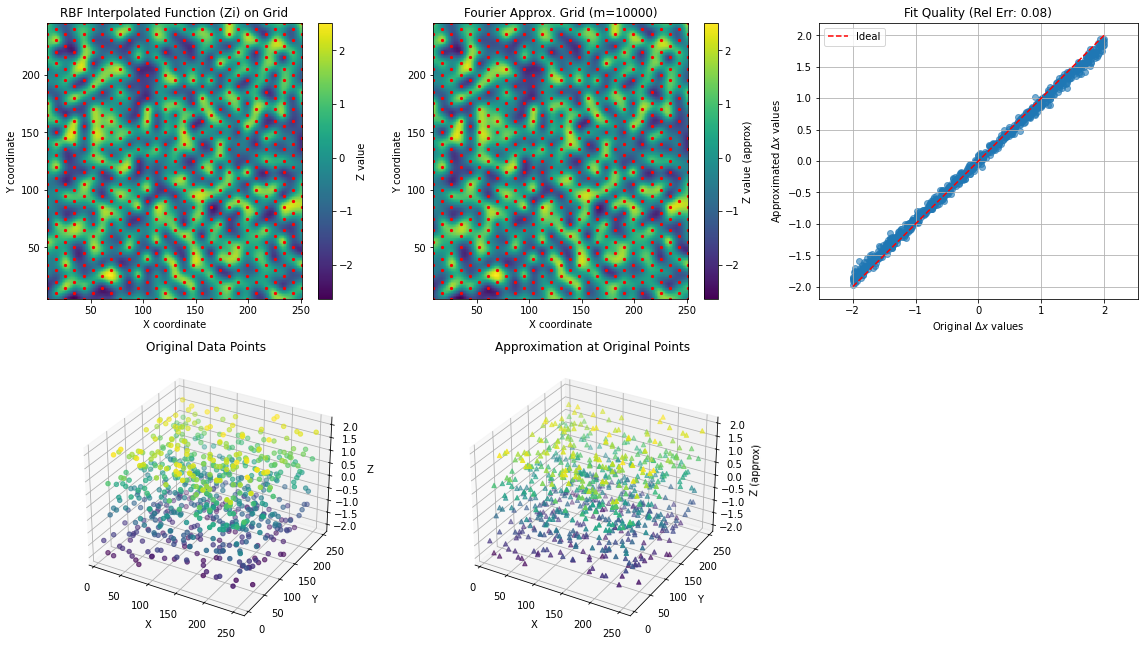


Extracted 10000 non-zero complex coefficients.
First 10 coefficients: [-0.18654944+4.44089210e-15j -0.01394789+1.09684616e-01j
 -0.07141351+1.39997254e-01j -0.02100908+1.78708187e-01j
  0.32913524+3.93631799e-01j -0.16045601-2.28413597e-01j
  0.25612797-1.52752783e-01j -0.15527227-3.02487854e-01j
 -0.28831371+3.49905323e-01j  0.19998283+3.31688518e-01j]


In [12]:
TARGET_RELATIVE_ERROR = 0.05
GRID_SIZE = 100
RBF_FUNCTION = 'thin_plate'

print(f"Original data points: {len(z)}")
print(f"Target relative error: {TARGET_RELATIVE_ERROR:.1%}")
print(f"Grid size for FFT: {GRID_SIZE}x{GRID_SIZE}")
print(f"RBF function: {RBF_FUNCTION}")

start_total_time = time.time()

start_rbf_time = time.time()
xi = np.linspace(x.min(), x.max(), GRID_SIZE)
yi = np.linspace(y.min(), y.max(), GRID_SIZE)
Xi, Yi = np.meshgrid(xi, yi)

rbf = Rbf(x, y, z, function=RBF_FUNCTION, smooth=0)
Zi = rbf(Xi, Yi)
end_rbf_time = time.time()

F_fft = fft2(Zi)
F_shifted = fftshift(F_fft)
power = np.abs(F_shifted)**2

power_flat = power.flatten()
idx_sorted = np.argsort(power_flat)[::-1]
total_coeffs = len(power_flat)
print(f"Total FFT coefficients: {total_coeffs}")

z_norm_factor = np.linalg.norm(z)

grid_interpolator = RegularGridInterpolator((yi, xi), Zi, bounds_error=False, fill_value=None)
original_points_stacked = np.vstack((y, x)).T

z_rbf_at_original = grid_interpolator(original_points_stacked)
rbf_error = np.linalg.norm(z - z_rbf_at_original) / z_norm_factor
print(f"Initial RBF error at original points: {rbf_error:.4f}")
if rbf_error > TARGET_RELATIVE_ERROR:
     print("Warning: Initial RBF interpolation error exceeds target. FFT approximation might not reach target.")

approx_interpolator = RegularGridInterpolator((yi, xi), np.zeros_like(Zi),
                                              bounds_error=False, fill_value=None)

best_m = -1
final_error = -1
final_coeffs_mask = None
final_z_approx_at_original = None

start_iter_time = time.time()
for m in range(1, total_coeffs + 1):
    mask = np.zeros(total_coeffs, dtype=bool)
    mask[idx_sorted[:m]] = True
    mask = mask.reshape(F_shifted.shape)

    F_trunc_shifted = F_shifted * mask
    Z_approx_grid = np.real(ifft2(ifftshift(F_trunc_shifted)))
    
    approx_interpolator.values = Z_approx_grid
    z_approx_at_original = approx_interpolator(original_points_stacked)

    current_error = np.linalg.norm(z - z_approx_at_original) / z_norm_factor

    if m % 1000 == 0 or m==1:
        print(f"  m = {m:5d}, Error = {current_error:.5f}")

    if current_error <= TARGET_RELATIVE_ERROR:
        print(f"\nTarget relative error {TARGET_RELATIVE_ERROR:.1%} reached!")
        print(f"Number of coefficients needed: {m}")
        print(f"Final relative error at original points: {current_error:.4f}")
        best_m = m
        final_error = current_error
        final_coeffs_mask = mask 
        final_z_approx_at_original = z_approx_at_original
        break
else:
    print("\nTarget relative error not reached within the maximum number of coefficients.")
    print(f"Minimum error achieved: {current_error:.4f} with {m} coefficients.")
    best_m = m
    final_error = current_error
    final_coeffs_mask = mask
    final_z_approx_at_original = z_approx_at_original

end_iter_time = time.time()
print(f"Coefficient search took {end_iter_time - start_iter_time:.2f} seconds.")


if best_m > 0:
    F_final_trunc_shifted = F_shifted * final_coeffs_mask
    print(f"\nReduced dimensionality: {best_m} complex coefficients")
    # Example Reconstruction (using stored info)
    # Need: F_final_trunc_shifted, xi, yi, original x, y
    Z_reconstructed_grid = np.real(ifft2(ifftshift(F_final_trunc_shifted)))
    reconstruction_interpolator = RegularGridInterpolator((yi, xi), Z_reconstructed_grid,
                                                        bounds_error=False, fill_value=None)
    original_points_stacked = np.vstack((y, x)).T
    z_reconstructed = reconstruction_interpolator(original_points_stacked)
    reconstruction_error = np.linalg.norm(z - z_reconstructed) / z_norm_factor
    print(f"Error check using reconstruction: {reconstruction_error:.4f}")


plt.figure(figsize=(16, 9))

plt.subplot(2, 3, 1)
plt.imshow(Zi, extent=[xi.min(), xi.max(), yi.min(), yi.max()], origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='Z value')
plt.scatter(x, y, c='red', s=5, label='Original Points')
plt.title("RBF Interpolated Function (Zi) on Grid")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
# plt.legend()

if best_m > 0:
    Z_approx_grid_final = np.real(ifft2(ifftshift(F_shifted * final_coeffs_mask)))
    plt.subplot(2, 3, 2)
    plt.imshow(Z_approx_grid_final, extent=[xi.min(), xi.max(), yi.min(), yi.max()], origin='lower', 
               aspect='auto', cmap='viridis')
    plt.colorbar(label='Z value (approx)')
    plt.scatter(x, y, c='red', s=5, label='Original Points')
    plt.title(f"Fourier Approx. Grid (m={best_m})")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    # plt.legend()

from mpl_toolkits.mplot3d import Axes3D
ax3 = plt.subplot(2, 3, 4, projection='3d')
scatter1 = ax3.scatter(x, y, z, c=z, cmap='viridis', marker='o', label='Original z', depthshade=True)
ax3.set_title("Original Data Points")
ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Z")
# plt.colorbar(scatter1, ax=ax3, shrink=0.6) # Add color bar if needed

if final_z_approx_at_original is not None:
    ax4 = plt.subplot(2, 3, 5, projection='3d')
    scatter2 = ax4.scatter(x, y, final_z_approx_at_original, c=final_z_approx_at_original, cmap='viridis', 
                           marker='^', label=f'Approx. z (m={best_m})', depthshade=True)
    ax4.set_title("Approximation at Original Points")
    ax4.set_xlabel("X")
    ax4.set_ylabel("Y")
    ax4.set_zlabel("Z (approx)")
    # plt.colorbar(scatter2, ax=ax4, shrink=0.6) # Add color bar if needed

ax3 = plt.subplot(2, 3, 3)
min_val = min(np.min(z), np.min(z_reconstructed))
max_val = max(np.max(z), np.max(z_reconstructed))
ax3.scatter(z, z_reconstructed, alpha=0.6)
ax3.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')
ax3.set_xlabel("Original $\Delta x$ values")
ax3.set_ylabel("Approximated $\Delta x$ values")
ax3.set_title(f"Fit Quality (Rel Err: {final_error:.2f})")
ax3.grid(True)
ax3.legend()
ax3.axis('equal')


plt.tight_layout()
end_total_time = time.time()
print(f"\nTotal script execution time: {end_total_time - start_total_time:.2f} seconds.")
plt.show()


kept_coefficients = F_shifted[final_coeffs_mask]
print(f"\nExtracted {len(kept_coefficients)} non-zero complex coefficients.")
print("First 10 coefficients:", kept_coefficients[:10])

Starting iterative Fourier approximation...
----------------------------------------
 M | N | Num Coeffs | Rel Error | Time (s) 
----------------------------------------
 0 | 0 |     1      |  0.9999   |   0.02  
 1 | 1 |     9      |  0.9919   |   0.00  
 2 | 2 |     25     |  0.9796   |   0.00  
 3 | 3 |     49     |  0.9645   |   0.00  
 4 | 4 |     81     |  0.9441   |   0.02  
 5 | 5 |    121     |  0.9180   |   0.03  
 6 | 6 |    169     |  0.8728   |   0.04  
 7 | 7 |    225     |  0.8240   |   0.06  
 8 | 8 |    289     |  0.7522   |   0.09  
 9 | 9 |    361     |  0.6851   |   0.14  
10 |10 |    441     |  0.5928   |   0.19  
11 |11 |    529     |  0.4556   |   0.25  
12 |12 |    625     |  0.3358   |   0.30  
13 |13 |    729     |  0.2635   |   0.37  
14 |14 |    841     |  0.2149   |   0.40  
15 |15 |    961     |  0.2149   |   0.42  
16 |16 |    1089    |  0.2149   |   0.43  
17 |17 |    1225    |  0.2149   |   0.56  
18 |18 |    1369    |  0.2149   |   0.49  
19 |19 |    1

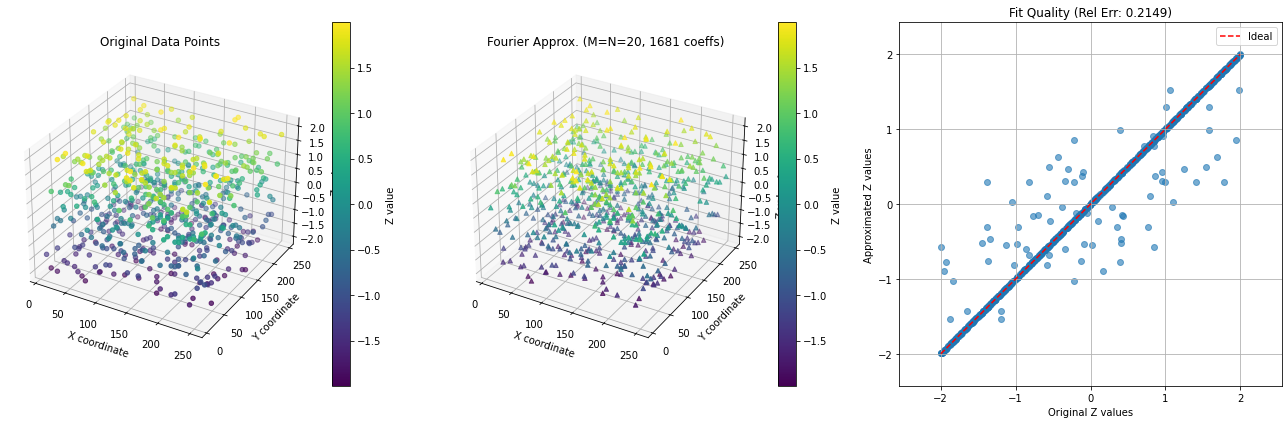


Reduced representation consists of:
- 1681 complex Fourier coefficients
- The corresponding 1681 (m, n) frequency pairs
- Normalization parameters: xmin=8.66, Lx=242.49, ymin=5.00, Ly=240.00


In [13]:
TARGET_RELATIVE_ERROR = 0.05
MAX_ORDER = 20

xmin, xmax = np.min(x), np.max(x)
ymin, ymax = np.min(y), np.max(y)
Lx = xmax - xmin
Ly = ymax - ymin
x_norm = (x - xmin) / Lx
y_norm = (y - ymin) / Ly

z_norm_factor = np.linalg.norm(z)

print("Starting iterative Fourier approximation...")
print("-" * 40)
print(" M | N | Num Coeffs | Rel Error | Time (s) ")
print("-" * 40)

best_coeffs = None
best_mn_pairs = None
best_M = -1
best_N = -1

for order in range(MAX_ORDER + 1):
    start_time = time.time()
    M = order
    N = order

    m_vals = np.arange(-M, M + 1)
    n_vals = np.arange(-N, N + 1)
    mn_pairs = np.array([(m, n) for m in m_vals for n in n_vals])
    num_coeffs = len(mn_pairs)

    A = np.exp(1j * 2 * np.pi * (mn_pairs[:, 0][None, :] * x_norm[:, None] +
                                  mn_pairs[:, 1][None, :] * y_norm[:, None]))

    try:
        coeffs, residuals, rank, s = np.linalg.lstsq(A, z, rcond=None)
    except np.linalg.LinAlgError:
        print(f"{M:^3}|{N:^3}| {num_coeffs:^10} | LinAlgError | ---")
        continue

    z_approx = np.real(A @ coeffs)
    relative_error = np.linalg.norm(z - z_approx) / z_norm_factor

    end_time = time.time()
    elapsed_time = end_time - start_time

    print(f"{M:^3}|{N:^3}| {num_coeffs:^10} | {relative_error:^9.4f} | {elapsed_time:^8.2f}")

    if relative_error <= TARGET_RELATIVE_ERROR:
        print("-" * 40)
        print(f"Target relative error {TARGET_RELATIVE_ERROR:.1%} reached at M=N={order}")
        best_coeffs = coeffs
        best_mn_pairs = mn_pairs
        best_M = M
        best_N = N
        break
    elif order == MAX_ORDER:
        print("-" * 40)
        print(f"Maximum order M=N={MAX_ORDER} reached.")
        print(f"Lowest relative error achieved: {relative_error:.4f}")
        best_coeffs = coeffs
        best_mn_pairs = mn_pairs
        best_M = M
        best_N = N

print(f"\nBest approximation details:")
print(f"  M = {best_M}, N = {best_N}")
print(f"  Number of complex coefficients = {len(best_coeffs)}")
final_error = np.linalg.norm(z - np.real(A @ best_coeffs)) / z_norm_factor
print(f"  Final relative error = {final_error:.4f}")

def reconstruct_fourier(x_new, y_new, coeffs, mn_pairs, xmin, Lx, ymin, Ly):
    x_new = np.asarray(x_new)
    y_new = np.asarray(y_new)

    x_new_norm = (x_new - xmin) / Lx
    y_new_norm = (y_new - ymin) / Ly

    A_new = np.exp(1j * 2 * np.pi * (mn_pairs[:, 0][None, :] * x_new_norm.flatten()[:, None] +
                                        mn_pairs[:, 1][None, :] * y_new_norm.flatten()[:, None]))

    z_new_approx = A_new @ coeffs
    return np.real(z_new_approx).reshape(x_new.shape)

z_reconstructed = reconstruct_fourier(x, y, best_coeffs, best_mn_pairs, xmin, Lx, ymin, Ly)
reconstruction_error = np.linalg.norm(z - z_reconstructed) / z_norm_factor
print(f"  Error check: Reconstruction error on original points = {reconstruction_error:.4f}")

# --- Visualization ---
fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(131, projection='3d')
sc1 = ax1.scatter(x, y, z, c=z, cmap='viridis', marker='o', label='Original Data')
ax1.set_title('Original Data Points')
ax1.set_xlabel('X coordinate')
ax1.set_ylabel('Y coordinate')
ax1.set_zlabel('Z value')
fig.colorbar(sc1, ax=ax1, label='Z value')

ax2 = fig.add_subplot(132, projection='3d')
sc2 = ax2.scatter(x, y, z_reconstructed, c=z_reconstructed, cmap='viridis', marker='^', label='Approximation',
                    vmin=np.min(z), vmax=np.max(z))
ax2.set_title(f'Fourier Approx. (M=N={best_M}, {len(best_coeffs)} coeffs)')
ax2.set_xlabel('X coordinate')
ax2.set_ylabel('Y coordinate')
ax2.set_zlabel('Z value (approx)')
fig.colorbar(sc2, ax=ax2, label='Z value')

ax3 = fig.add_subplot(133)
min_val = min(np.min(z), np.min(z_reconstructed))
max_val = max(np.max(z), np.max(z_reconstructed))
ax3.scatter(z, z_reconstructed, alpha=0.6)
ax3.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')
ax3.set_xlabel("Original Z values")
ax3.set_ylabel("Approximated Z values")
ax3.set_title(f"Fit Quality (Rel Err: {relative_error:.4f})")
ax3.grid(True)
ax3.legend()
ax3.axis('equal')

plt.tight_layout()
plt.show()

# You can now use 'best_coeffs' and 'best_mn_pairs' as the reduced representation
# The dimension is len(best_coeffs) complex numbers.
# You also need xmin, Lx, ymin, Ly for reconstruction.
print("\nReduced representation consists of:")
print(f"- {len(best_coeffs)} complex Fourier coefficients")
print(f"- The corresponding {len(best_mn_pairs)} (m, n) frequency pairs")
print(f"- Normalization parameters: xmin={xmin:.2f}, Lx={Lx:.2f}, ymin={ymin:.2f}, Ly={Ly:.2f}")

# Taylor Expansion

In [14]:
from scipy.interpolate import lagrange # For a different Lagrange interpretation (not used in main solution)
from scipy.special import eval_legendre, eval_chebyt, legendre, chebyt # For Legendre and Chebyshev
from scipy.linalg import lstsq # For least squares fitting

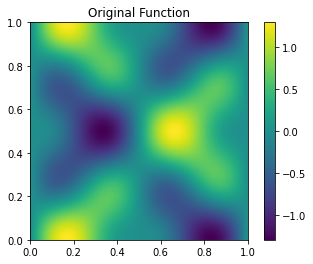

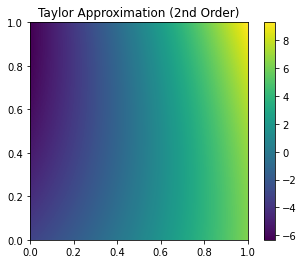

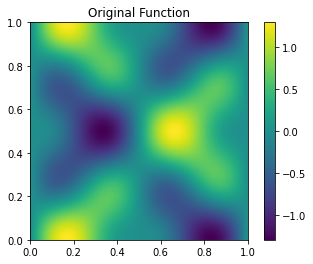

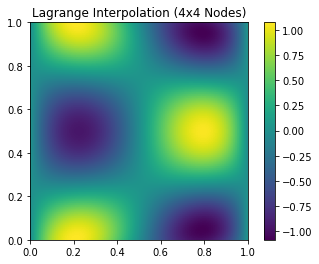

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Define grid and function
# ---------------------------
nx, ny = 100, 100
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y)

def F(x, y):
    return np.sin(2 * np.pi * x) * np.cos(2 * np.pi * y) \
           + 0.5 * np.sin(4 * np.pi * x) * np.cos(4 * np.pi * y)

Z = F(X, Y)

# ---------------------------
# 1. Taylor Approximation (2nd order at center)
# ---------------------------
# Expansion point
x0, y0 = 0.5, 0.5
dx = x[1] - x[0]
dy = y[1] - y[0]

ix = np.argmin(np.abs(x - x0))
iy = np.argmin(np.abs(y - y0))

f0  = Z[iy, ix]
fx  = (Z[iy, ix+1] - Z[iy, ix-1]) / (2*dx)
fy  = (Z[iy+1, ix] - Z[iy-1, ix]) / (2*dy)
fxx = (Z[iy, ix+1] - 2*Z[iy, ix] + Z[iy, ix-1]) / (dx**2)
fyy = (Z[iy+1, ix] - 2*Z[iy, ix] + Z[iy-1, ix]) / (dy**2)
fxy = (Z[iy+1, ix+1] - Z[iy+1, ix-1] - Z[iy-1, ix+1] + Z[iy-1, ix-1]) / (4*dx*dy)

Z_taylor = (f0 +
            fx*(X - x0) + fy*(Y - y0) +
            0.5*fxx*(X - x0)**2 + 0.5*fyy*(Y - y0)**2 +
            fxy*(X - x0)*(Y - y0))

# Plot original
plt.figure()
plt.imshow(Z, extent=[0, 1, 0, 1], origin='lower')
plt.title("Original Function")
plt.colorbar()
plt.show()

# Plot Taylor approximation
plt.figure()
plt.imshow(Z_taylor, extent=[0, 1, 0, 1], origin='lower')
plt.title("Taylor Approximation (2nd Order)")
plt.colorbar()
plt.show()

# ---------------------------
# 2. Lagrange Polynomial Interpolation
# ---------------------------
deg_x, deg_y = 4, 4
idx_x = np.linspace(0, nx-1, deg_x+1, dtype=int)
idx_y = np.linspace(0, ny-1, deg_y+1, dtype=int)
x_nodes = x[idx_x]
y_nodes = y[idx_y]

# Sample weights at nodes
W = F(*np.meshgrid(x_nodes, y_nodes))

# Build 1D Lagrange basis for x and y
basis_x = np.zeros((nx, deg_x+1))
for j in range(deg_x+1):
    basis_x[:, j] = 1
    for k in range(deg_x+1):
        if k != j:
            basis_x[:, j] *= (x - x_nodes[k]) / (x_nodes[j] - x_nodes[k])

basis_y = np.zeros((ny, deg_y+1))
for i in range(deg_y+1):
    basis_y[:, i] = 1
    for k in range(deg_y+1):
        if k != i:
            basis_y[:, i] *= (y - y_nodes[k]) / (y_nodes[i] - y_nodes[k])

# Compute 2D Lagrange interpolant
Z_lagrange = basis_y.dot(W).dot(basis_x.T)

# Plot original again for comparison
plt.figure()
plt.imshow(Z, extent=[0, 1, 0, 1], origin='lower')
plt.title("Original Function")
plt.colorbar()
plt.show()

# Plot Lagrange interpolation
plt.figure()
plt.imshow(Z_lagrange, extent=[0, 1, 0, 1], origin='lower')
plt.title("Lagrange Interpolation (4x4 Nodes)")
plt.colorbar()
plt.show()


# Orthogonal (Legendre) Polynomial

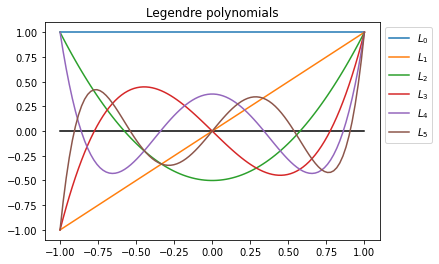

In [16]:
from scipy.special import legendre

def L(x,n):
    Leg = legendre(n)
    y = Leg(x)
    return y

xx = np.linspace(-1,1,100)
plt.plot(xx,0*xx,'k-')
for i in range(6):
    plt.plot(xx,L(xx,i),label=r'$L_'+str(i)+'$') 
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', ncol=1)  
plt.title('Legendre polynomials')
plt.show() 

# Least Squares

In [17]:
import sympy as sym

def least_squares(f, psi, Omega):
    N = len(psi) - 1
    A = sym.zeros((N+1, N+1))
    b = sym.zeros((N+1, 1))
    x = sym.Symbol('x')
    for i in range(N+1):
        for j in range(i, N+1):
            A[i,j] = sym.integrate(psi[i]*psi[j],
                                  (x, Omega[0], Omega[1]))
            A[j,i] = A[i,j]
        b[i,0] = sym.integrate(psi[i]*f, (x, Omega[0], Omega[1]))
    c = A.LUsolve(b)
    # Note: c is a sympy Matrix object, solution is in c[:,0]
    u = 0
    for i in range(len(psi)):
        u += c[i,0]*psi[i]
    return u, c

In [18]:
def least_squares(f, psi, Omega, symbolic=True):
    N = len(psi) - 1
    A = sym.zeros((N+1, N+1))
    b = sym.zeros((N+1, 1))
    x = sym.Symbol('x')
    for i in range(N+1):
        for j in range(i, N+1):
            integrand = psi[i]*psi[j]
            if symbolic:
                I = sym.integrate(integrand, (x, Omega[0], Omega[1]))
            if not symbolic or isinstance(I, sym.Integral):
                # Could not integrate symbolically,
                # fall back on numerical integration
                integrand = sym.lambdify([x], integrand)
                I = sym.mpmath.quad(integrand, [Omega[0], Omega[1]])
            A[i,j] = A[j,i] = I

        integrand = psi[i]*f
        if symbolic:
            I = sym.integrate(integrand, (x, Omega[0], Omega[1]))
        if not symbolic or isinstance(I, sym.Integral):
            integrand = sym.lambdify([x], integrand)
            I = sym.mpmath.quad(integrand, [Omega[0], Omega[1]])
        b[i,0] = I
    c = A.LUsolve(b)  # symbolic solve
    # c is a sympy Matrix object, numbers are in c[i,0]
    c = [sym.simplify(c[i,0]) for i in range(c.shape[0])]
    u = sum(c[i]*psi[i] for i in range(len(psi)))
    return u, c

In [19]:
def comparison_plot(f, u, Omega, filename='tmp.pdf'):
    x = sym.Symbol('x')
    f = sym.lambdify([x], f, modules="numpy")
    u = sym.lambdify([x], u, modules="numpy")
    resolution = 401  # no of points in plot
    xcoor  = linspace(Omega[0], Omega[1], resolution)
    exact  = f(xcoor)
    approx = u(xcoor)
    plot(xcoor, approx)
    hold('on')
    plot(xcoor, exact)
    legend(['approximation', 'exact'])
    savefig(filename)

In [20]:
x = sym.Symbol('x')
f = 10*(x-1)**2-1
u, c = least_squares(f=f, psi=[1, x, x**2], Omega=[1, 2])
print(u)
print(sym.expand(f))

TypeError: '<' not supported between instances of 'tuple' and 'int'

# ETC


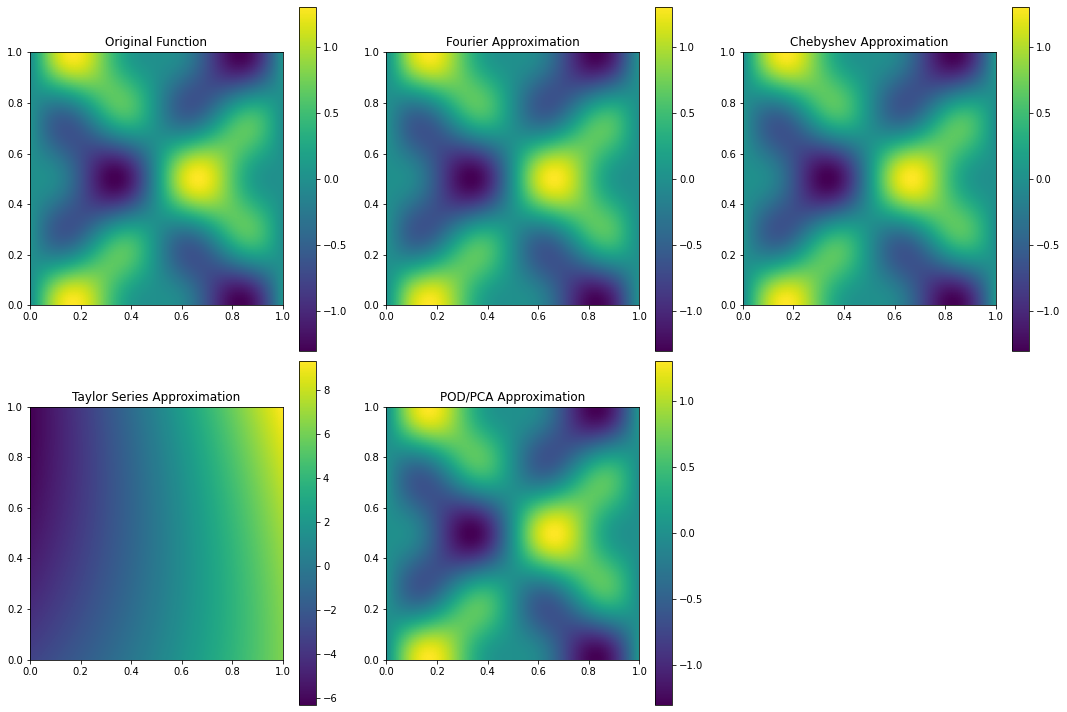

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander2d, chebval2d

# ---------------------------
# Define a sample 2D function
# ---------------------------
nx, ny = 100, 100
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y)

# Example function resembling a GP mean function output
def f(x, y):
    return np.sin(2*np.pi*x) * np.cos(2*np.pi*y) + 0.5*np.sin(4*np.pi*x) * np.cos(4*np.pi*y)

F = f(X, Y)

# ---------------------------
# 1. Fourier Series Approximation via FFT
# ---------------------------
# Compute the 2D FFT
F_fft = np.fft.fft2(F)
F_fft_shift = np.fft.fftshift(F_fft)

# Create a mask that keeps only the low-frequency components (a 10x10 block around the center)
keep = 10
mask = np.zeros_like(F_fft_shift, dtype=bool)
center_x, center_y = nx//2, ny//2
mask[center_x-keep:center_x+keep, center_y-keep:center_y+keep] = True

# Truncate the FFT coefficients and perform the inverse FFT
F_fft_truncated = np.zeros_like(F_fft_shift)
F_fft_truncated[mask] = F_fft_shift[mask]
F_fft_truncated_unshift = np.fft.ifftshift(F_fft_truncated)
F_fourier_approx = np.fft.ifft2(F_fft_truncated_unshift).real

# ---------------------------
# 2. Chebyshev Polynomial Approximation
# ---------------------------
# Chebyshev polynomials are defined on [-1, 1], so we remap x and y:
x_cheb = 2 * x - 1
y_cheb = 2 * y - 1
X_cheb, Y_cheb = np.meshgrid(x_cheb, y_cheb)

# Set degrees for the expansion in x and y
deg_x, deg_y = 10, 10

# Build the 2D Chebyshev Vandermonde matrix over the grid (flattened)
V = chebvander2d(X_cheb.ravel(), Y_cheb.ravel(), [deg_x, deg_y])

# Solve the least squares problem to obtain the Chebyshev coefficients
coeffs, _, _, _ = np.linalg.lstsq(V, F.ravel(), rcond=None)

# Reshape coefficients into a 2D array for evaluation and reconstruct the function
F_cheb_approx = chebval2d(X_cheb, Y_cheb, coeffs.reshape(deg_x+1, deg_y+1))

# ---------------------------
# 3. Taylor Series Expansion (Local, up to 2nd order)
# ---------------------------
# Choose the expansion point (e.g., the center of the domain)
x0, y0 = 0.5, 0.5
dx = x[1] - x[0]
dy = y[1] - y[0]

# Find indices near the expansion point
ix = np.argmin(np.abs(x - x0))
iy = np.argmin(np.abs(y - y0))

# Compute the function value and finite difference approximations for derivatives at (x0,y0)
f0 = F[iy, ix]
fx = (F[iy, ix+1] - F[iy, ix-1]) / (2*dx)
fy = (F[iy+1, ix] - F[iy-1, ix]) / (2*dy)
fxx = (F[iy, ix+1] - 2*F[iy, ix] + F[iy, ix-1]) / (dx**2)
fyy = (F[iy+1, ix] - 2*F[iy, ix] + F[iy-1, ix]) / (dy**2)
fxy = (F[iy+1, ix+1] - F[iy+1, ix-1] - F[iy-1, ix+1] + F[iy-1, ix-1]) / (4*dx*dy)

# Build the Taylor approximation for each grid point
F_taylor_approx = (f0 +
                   fx * (X - x0) +
                   fy * (Y - y0) +
                   0.5 * fxx * (X - x0)**2 +
                   0.5 * fyy * (Y - y0)**2 +
                   fxy * (X - x0) * (Y - y0))

# ---------------------------
# 4. Proper Orthogonal Decomposition (POD) / PCA via SVD
# ---------------------------
# For POD, we treat the 2D function F as a data matrix.
# First subtract the mean (here we compute the mean across rows)
F_mean = np.mean(F, axis=0)
F_centered = F - F_mean

# Compute the Singular Value Decomposition (SVD)
U, S, Vh = np.linalg.svd(F_centered, full_matrices=False)

# Choose a number of modes to retain; fewer modes mean a more compact approximation.
num_modes = 5
F_pod_approx = np.dot(U[:, :num_modes],
                      np.dot(np.diag(S[:num_modes]), Vh[:num_modes, :])) + F_mean

# ---------------------------
# Plotting All Approximations
# ---------------------------
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# Original function
im0 = axs[0, 0].imshow(F, extent=[0, 1, 0, 1], origin='lower')
axs[0, 0].set_title("Original Function")
fig.colorbar(im0, ax=axs[0, 0])

# Fourier approximation
im1 = axs[0, 1].imshow(F_fourier_approx, extent=[0, 1, 0, 1], origin='lower')
axs[0, 1].set_title("Fourier Approximation")
fig.colorbar(im1, ax=axs[0, 1])

# Chebyshev approximation
im2 = axs[0, 2].imshow(F_cheb_approx, extent=[0, 1, 0, 1], origin='lower')
axs[0, 2].set_title("Chebyshev Approximation")
fig.colorbar(im2, ax=axs[0, 2])

# Taylor series approximation
im3 = axs[1, 0].imshow(F_taylor_approx, extent=[0, 1, 0, 1], origin='lower')
axs[1, 0].set_title("Taylor Series Approximation")
fig.colorbar(im3, ax=axs[1, 0])

# POD/PCA approximation
im4 = axs[1, 1].imshow(F_pod_approx, extent=[0, 1, 0, 1], origin='lower')
axs[1, 1].set_title("POD/PCA Approximation")
fig.colorbar(im4, ax=axs[1, 1])

# Hide the unused subplot
axs[1, 2].axis('off')

plt.tight_layout()
plt.show()
